In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns


In [2]:
df = pd.read_excel("OnlineRetail.xlsx")

In [3]:
df.head()

,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country
0,536365,85123A,WHITE HANGING HEART T-LIGHT HOLDER,6,2010-12-01 08:26:00,2.55,17850.0,United Kingdom
1,536365,71053,WHITE METAL LANTERN,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom
2,536365,84406B,CREAM CUPID HEARTS COAT HANGER,8,2010-12-01 08:26:00,2.75,17850.0,United Kingdom
3,536365,84029G,KNITTED UNION FLAG HOT WATER BOTTLE,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom
4,536365,84029E,RED WOOLLY HOTTIE WHITE HEART.,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom


In [4]:
#droping rows without CustomerID
df = df.dropna(subset=['CustomerID'])

#converting InvoiceDate to datetime
df['InvoiceDate'] = pd.to_datetime(df['InvoiceDate'])

#emoving negative quantities & prices (returns/cancellations)
df = df[(df['Quantity'] > 0) & (df['UnitPrice'] > 0)]

#creating total price
df['TotalPrice'] = df['Quantity'] * df['UnitPrice']

In [5]:
#chosing a reference date
reference_date = df['InvoiceDate'].max() + pd.Timedelta(days=1)
#computing RFM
rfm = df.groupby('CustomerID').agg({
    'InvoiceDate': lambda x: (reference_date - x.max()).days,  # Recency
    'InvoiceNo': 'nunique',                                     # Frequency
    'TotalPrice': 'sum'                                         # Monetary
})

rfm.columns = ['Recency', 'Frequency', 'Monetary']
rfm.head()

,Recency,Frequency,Monetary
CustomerID,,,
12346.0,326,1,77183.60
12347.0,2,7,4310.00
12348.0,75,4,1797.24
12349.0,19,1,1757.55
12350.0,310,1,334.40


In [6]:
#assigning the RFM scores (1-4)

#ranking values to avoid duplicate bin issues
rfm['R_rank'] = rfm['Recency'].rank(method='first', ascending=True)
rfm['F_rank'] = rfm['Frequency'].rank(method='first', ascending=True)
rfm['M_rank'] = rfm['Monetary'].rank(method='first', ascending=True)

#applying qcut on ranks
rfm['R_score'] = pd.qcut(rfm['R_rank'], 4, labels=[4,3,2,1])
rfm['F_score'] = pd.qcut(rfm['F_rank'], 4, labels=[1,2,3,4])
rfm['M_score'] = pd.qcut(rfm['M_rank'], 4, labels=[1,2,3,4])

#building the RFM score
rfm['RFM_Score'] = rfm['R_score'].astype(str) + \
                   rfm['F_score'].astype(str) + \
                   rfm['M_score'].astype(str)
rfm.head()

,Recency,Frequency,Monetary,R_rank,F_rank,M_rank,R_score,F_score,M_score,RFM_Score
CustomerID,,,,,,,,,,
12346.0,326,1,77183.60,4175.0,1.0,4329.0,1,1,4,114
12347.0,2,7,4310.00,94.0,3639.0,4003.0,4,4,4,444
12348.0,75,4,1797.24,2675.0,2837.0,3333.0,2,3,4,234
12349.0,19,1,1757.55,1126.0,2.0,3305.0,3,1,4,314
12350.0,310,1,334.40,4106.0,3.0,1229.0,1,1,2,112


In [7]:
#customer segmentation
def segment_customer(row):
    if row['R_score'] == 4 and row['F_score'] == 4 and row['M_score'] == 4:
        return 'Champions'
    elif row['R_score'] >= 3 and row['F_score'] >= 3:
        return 'Loyal Customers'
    elif row['R_score'] >= 3:
        return 'Potential Loyalists'
    elif row['R_score'] == 2:
        return 'At Risk'
    else:
        return 'Lost Customers'

rfm['Segment'] = rfm.apply(segment_customer, axis=1)
rfm['Segment'].value_counts()

Segment
Lost Customers         1085
At Risk                1084
Loyal Customers        1036
Potential Loyalists     655
Champions               478
Name: count, dtype: int64

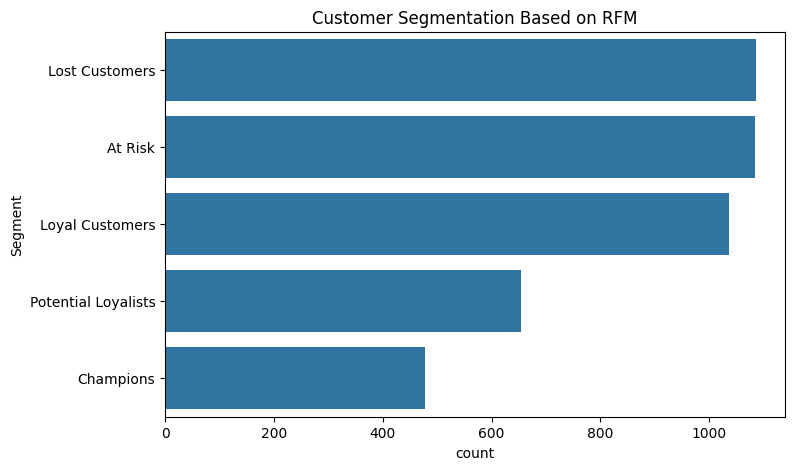

In [8]:
#visualising segments
plt.figure(figsize=(8,5))
sns.countplot(y='Segment', data=rfm, order=rfm['Segment'].value_counts().index)
plt.title("Customer Segmentation Based on RFM")
plt.show()

### Marketing Ideas Based on RFM Segmentation

- **Champions:**  
  These are the highest-value customers. They should be rewarded with VIP offers, early access to new products, and exclusive loyalty rewards to maintain long-term engagement.

- **Loyal Customers:**  
  Loyal customers purchase frequently and show strong engagement. Reward points and personalized offers can be used to encourage higher spending and repeat purchases.

- **Potential Loyalists:**  
  These customers have purchased recently but are not yet frequent buyers. Welcome discounts and targeted promotions can help convert them into loyal customers.

- **At-Risk Customers:**  
  These customers have become less active over time. Re-engagement emails and “We miss you” discounts can be effective in bringing them back.

- **Lost Customers:**  
  These customers have not made purchases for a long period. Win-back campaigns with special offers can be used to attempt reactivation.